In [1]:
import pandas as pd
import csv
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [2]:
#Open database,skipping the shifted rows
books = pd.read_csv("books.csv", on_bad_lines = "skip")
books

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic
...,...,...,...,...,...,...,...,...,...,...,...,...
11118,45631,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,1560254416,9781560254416,eng,512,156,20,12/21/2004,Da Capo Press
11119,45633,You Bright and Risen Angels,William T. Vollmann,4.08,0140110879,9780140110876,eng,635,783,56,12/1/1988,Penguin Books
11120,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,0140131965,9780140131963,eng,415,820,95,8/1/1993,Penguin Books
11121,45639,Poor People,William T. Vollmann,3.72,0060878827,9780060878825,eng,434,769,139,2/27/2007,Ecco


In [3]:
#Fix the shifted rows who are seperated by a comma(4 rows)
input_file = "books.csv"
output_file = "clean_books.csv"
 
with open(input_file, "r", encoding="utf-8", newline="") as f_in, open(
    output_file, "w", encoding="utf-8", newline=""
) as f_out:
  reader = csv.reader(f_in)
  writer = csv.writer(f_out)
 
  header = next(reader)
  expected_len = len(header)
  writer.writerow(header)
 
  for row in reader:
    if len(row) > expected_len:
      excess = len(row) - expected_len
      fixed_row = row[:2] + [",".join(row[2 : 2 + excess + 1])] + row[2 + excess + 1 :]
      writer.writerow(fixed_row)
    else:
      writer.writerow(row)

In [4]:
# New database with fixed rows
clean_books = pd.read_csv("clean_books.csv")
clean_books


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic
...,...,...,...,...,...,...,...,...,...,...,...,...
11122,45631,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,1560254416,9781560254416,eng,512,156,20,12/21/2004,Da Capo Press
11123,45633,You Bright and Risen Angels,William T. Vollmann,4.08,0140110879,9780140110876,eng,635,783,56,12/1/1988,Penguin Books
11124,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,0140131965,9780140131963,eng,415,820,95,8/1/1993,Penguin Books
11125,45639,Poor People,William T. Vollmann,3.72,0060878827,9780060878825,eng,434,769,139,2/27/2007,Ecco


In [5]:
#checking for leading spaces in the rest of the dataset
clean_books = clean_books.apply(lambda c: c.str.strip() if c.dtype == "object" else c)
for col in clean_books.select_dtypes(include="object").columns:
    s = clean_books[col].astype(str)
    print(f"{col:18s} leading_spaces remaining: {(s != s.str.strip()).sum()}")

title              leading_spaces remaining: 0
authors            leading_spaces remaining: 0
isbn               leading_spaces remaining: 0
language_code      leading_spaces remaining: 0
publication_date   leading_spaces remaining: 0
publisher          leading_spaces remaining: 0


In [6]:
#checking for double spaces in string columns and removing them
for col in ['title', 'authors', 'publisher']:
    clean_books[col] = clean_books[col].str.replace(r'\s+', ' ', regex=True).str.strip()
for col in clean_books.select_dtypes(include="object").columns:
    s = clean_books[col].astype(str)
    doubles  = s.str.contains(r"\s{2,}", regex=True).sum()
    print(f"{col:18s} doubles_spaces: {doubles:5d}")

title              doubles_spaces:     0
authors            doubles_spaces:     0
isbn               doubles_spaces:     0
language_code      doubles_spaces:     0
publication_date   doubles_spaces:     0
publisher          doubles_spaces:     0


In [7]:
#check for duplicates for the dataset
duplicates = clean_books[clean_books.duplicated()]
print("number of identical rows:", len(duplicates))


number of identical rows: 0


In [8]:
#check for duplicated authors and titles,we will keep them
duplicates = clean_books[clean_books.duplicated(subset=['title', 'authors'], keep = False)]
print ("Number of identical titles and author name", len(duplicates))
duplicates.head(10)
 

Number of identical titles and author name 591


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
9,14,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,1400052920,9781400052929,eng,215,4930,460,8/3/2004,Crown
12,21,A Short History of Nearly Everything,Bill Bryson,4.21,076790818X,9780767908184,eng,544,248558,9396,9/14/2004,Broadway Books
13,22,Bill Bryson's African Diary,Bill Bryson,3.44,0767915062,9780767915069,eng,55,7270,499,12/3/2002,Broadway Books
22,31,The Lord of the Rings (The Lord of the Rings #...,J.R.R. Tolkien,4.50,0618517650,9780618517657,eng,1184,1710,91,10/21/2004,Houghton Mifflin Harcourt
23,34,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,4.36,0618346252,9780618346257,eng,398,2128944,13670,9/5/2003,Houghton Mifflin Harcourt
39,67,The Known World,Edward P. Jones,3.83,0061159174,9780061159176,eng,388,29686,2626,8/29/2006,Amistad
41,69,The Known World,Edward P. Jones,3.83,0060749911,9780060749910,eng,576,22,3,6/15/2004,Harper
65,103,God Emperor of Dune (Dune Chronicles #4),Frank Herbert,3.84,0441294677,9780441294671,eng,423,2785,166,6/15/1987,Ace Books
69,109,Heretics of Dune (Dune Chronicles #5),Frank Herbert,3.86,0399128980,9780399128981,eng,480,272,20,4/16/1984,Putnam
71,117,Heretics of Dune (Dune Chronicles #5),Frank Herbert,3.86,0441328008,9780441328000,eng,471,45388,644,8/15/1987,Ace Books


In [9]:
#check for missing data
clean_books.isnull().sum()

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

In [10]:
#checking for leading spaces in headers and removing them
clean_books.columns = clean_books.columns.str.strip()
clean_books.columns.tolist()

['bookID',
 'title',
 'authors',
 'average_rating',
 'isbn',
 'isbn13',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publication_date',
 'publisher']

In [11]:
#Droping rows with average_ratings of 0
clean_books = clean_books.loc[clean_books["average_rating"] > 0]
zero_rating= (clean_books["average_rating"] == 0).any()
print("Is there a zero average_rating?:", zero_rating)
print("Number of rows with valid average_rating:",len(clean_books))


Is there a zero average_rating?: False
Number of rows with valid average_rating: 11101


In [12]:
#droping the columns 'isbn' and 'isbn13'
clean_books = clean_books.drop(columns=['bookID','isbn','isbn13'])
clean_books

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,eng,352,6333,244,11/1/2003,Scholastic
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,Harry Potter Boxed Set Books 1-5 (Harry Potter...,J.K. Rowling/Mary GrandPré,4.78,eng,2690,41428,164,9/13/2004,Scholastic
...,...,...,...,...,...,...,...,...,...
11122,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,eng,512,156,20,12/21/2004,Da Capo Press
11123,You Bright and Risen Angels,William T. Vollmann,4.08,eng,635,783,56,12/1/1988,Penguin Books
11124,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,eng,415,820,95,8/1/1993,Penguin Books
11125,Poor People,William T. Vollmann,3.72,eng,434,769,139,2/27/2007,Ecco


In [13]:
#check data type for each column
clean_books.dtypes

title                  object
authors                object
average_rating        float64
language_code          object
num_pages               int64
ratings_count           int64
text_reviews_count      int64
publication_date       object
publisher              object
dtype: object

#trying to convert publication date to dateime format but error because of wrong data
clean_books["publication_date"]= pd.to_datetime(clean_books["publication_date"], format='mixed')
clean_books["publication_date"] = clean_books["publication_date"].dt.year
clean_books["publication_date"]

In [14]:
#splitting month,day and year and keeping only year to minimize inacurracies
clean_books[["month","day","year"]]= clean_books["publication_date"].str.split("/", expand= True)
clean_books = clean_books.drop(columns=['publication_date','month','day'])
clean_books

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count,publisher,year
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,eng,652,2095690,27591,Scholastic Inc.,2006
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,eng,870,2153167,29221,Scholastic Inc.,2004
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,eng,352,6333,244,Scholastic,2003
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,eng,435,2339585,36325,Scholastic Inc.,2004
4,Harry Potter Boxed Set Books 1-5 (Harry Potter...,J.K. Rowling/Mary GrandPré,4.78,eng,2690,41428,164,Scholastic,2004
...,...,...,...,...,...,...,...,...,...
11122,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,eng,512,156,20,Da Capo Press,2004
11123,You Bright and Risen Angels,William T. Vollmann,4.08,eng,635,783,56,Penguin Books,1988
11124,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,eng,415,820,95,Penguin Books,1993
11125,Poor People,William T. Vollmann,3.72,eng,434,769,139,Ecco,2007


In [15]:
#renaming year to publication_year 
clean_books= clean_books.rename(columns={'year': 'publication_year'})
list(clean_books)

['title',
 'authors',
 'average_rating',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publisher',
 'publication_year']

In [16]:
#Converting publication year to integer
clean_books["publication_year"]= clean_books["publication_year"].astype(int)
clean_books.dtypes

title                  object
authors                object
average_rating        float64
language_code          object
num_pages               int64
ratings_count           int64
text_reviews_count      int64
publisher              object
publication_year        int64
dtype: object

In [17]:
#Check if book is audiobook or printed
publication_keyword = r'audio|tantor|listening library|recorded books|books on tape|highbridge|your coach'
title_keyword = r'audio|unabridged|abridged|\bcd\b|audiobook|spoken|cassette'

clean_books['is_audiobook'] = (
    clean_books['publisher'].str.contains(publication_keyword, case=False) |
    clean_books['title'].str.contains(title_keyword, case=False)
).astype(int)
print("audiobooks flagged:", clean_books['is_audiobook'].sum())
clean_books[clean_books['is_audiobook'] == 1][['title','publisher','is_audiobook']].sample(15)

audiobooks flagged: 232


,title,publisher,is_audiobook
4169,Emma,Audio Partners,1
8506,The Stephen King Collection: Stories from Nigh...,Random House Audio,1
5800,One Shot (Jack Reacher #9),Brilliance Audio,1
8522,The Monkey,Random House Audio,1
5843,Point Of Impact (Bob Lee Swagger #1),RH Audio,1
3340,The Poetry of Robert Frost: The Collected Poem...,Owl Books,1
3488,The Shining,Simon & Schuster Audio,1
5913,Stargirl LitPlans on CD,Teacher's Pet Publications,1
5798,Without Fail (Jack Reacher #6),Brilliance Audio,1
5806,The Enemy (Jack Reacher #8),Brilliance Audio,1


In [18]:
#Replacing number of pages for non audiobooks by the median for books with num_page=0
median_pages = clean_books.loc[clean_books["num_pages"] > 0,"num_pages"].median()
print_books_missing_pages = (clean_books["num_pages"] == 0) & (clean_books["is_audiobook"] == 0)
clean_books.loc[print_books_missing_pages, "num_pages"] = median_pages
print("Audiobooks with zero pages:", clean_books[clean_books["num_pages"]== 0]["is_audiobook"].sum())
n_affected = print_books_missing_pages.sum()
print(f"The median number of pages is {median_pages:.0f} and {n_affected} books were affected")

Audiobooks with zero pages: 52
The median number of pages is 302 and 24 books were affected


In [19]:
#Changing num_pages back to integer
clean_books["num_pages"] = clean_books["num_pages"].astype(int)
clean_books.dtypes

title                  object
authors                object
average_rating        float64
language_code          object
num_pages               int64
ratings_count           int64
text_reviews_count      int64
publisher              object
publication_year        int64
is_audiobook            int64
dtype: object

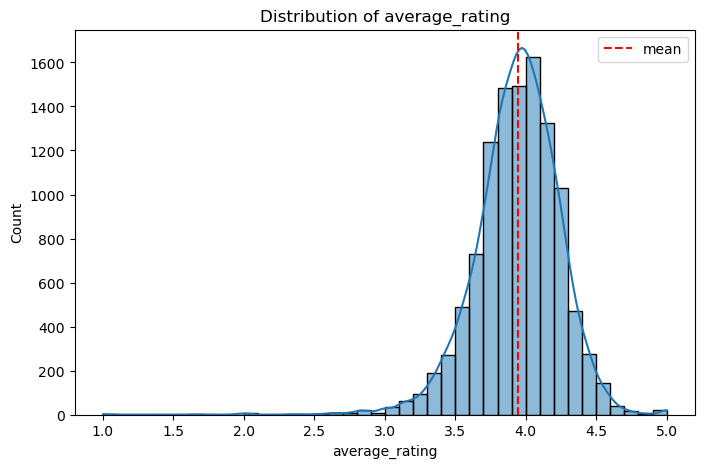

In [20]:
# Hystogram plot of "average_rating"
plt.figure(figsize=(8,5))
sns.histplot(clean_books['average_rating'], bins=40, kde=True)
plt.axvline(clean_books['average_rating'].mean(), color='red', ls='--', label='mean')
plt.title('Distribution of average_rating'); plt.legend()
plt.show()

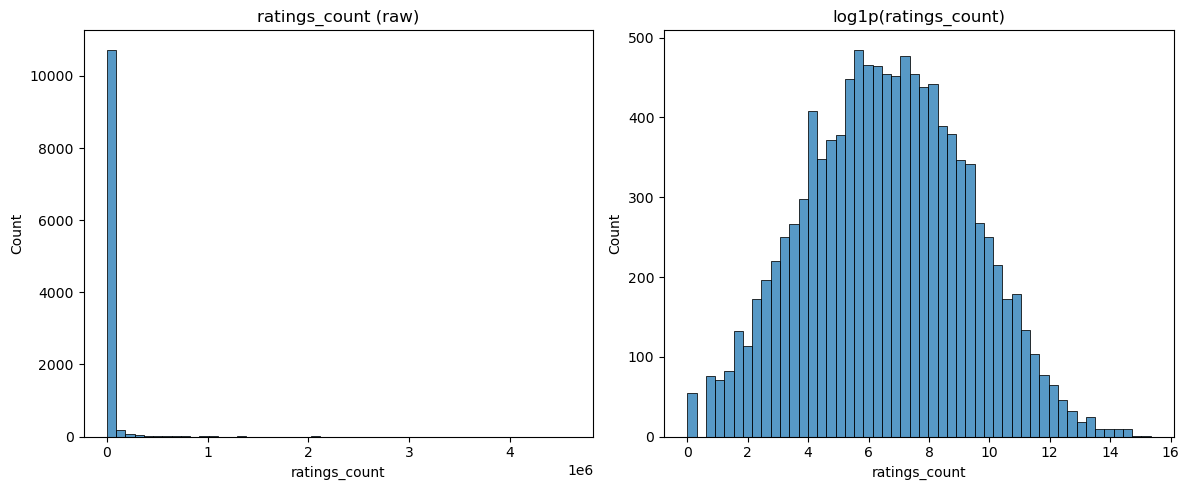

In [21]:
# Plotting "rating_count" raw vs log
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(clean_books['ratings_count'], bins=50, ax=axes[0])
axes[0].set_title('ratings_count (raw)')
sns.histplot(np.log1p(clean_books['ratings_count']), bins=50, ax=axes[1])
axes[1].set_title('log1p(ratings_count)')
plt.tight_layout(); plt.show()

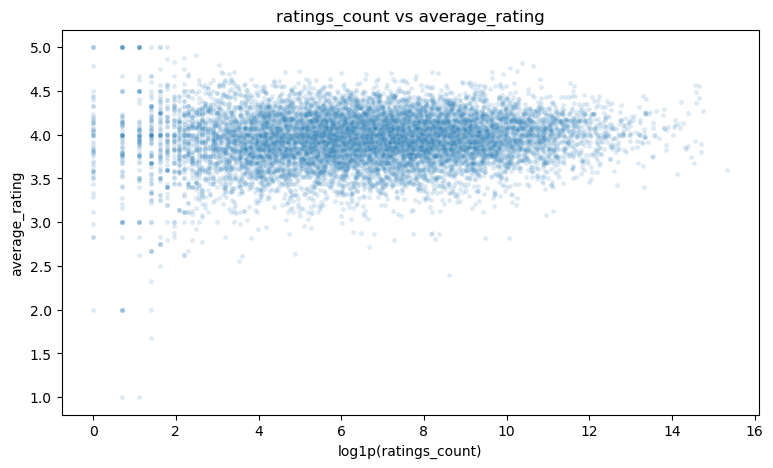

In [22]:
# Plotting average_rating vs rating_count(with log of rating_counts)
plt.figure(figsize=(9,5))
sns.scatterplot(x=np.log1p(clean_books['ratings_count']),
                y=clean_books['average_rating'], alpha=0.15, s=12)
plt.xlabel('log1p(ratings_count)'); plt.ylabel('average_rating')
plt.title('ratings_count vs average_rating')
plt.show()

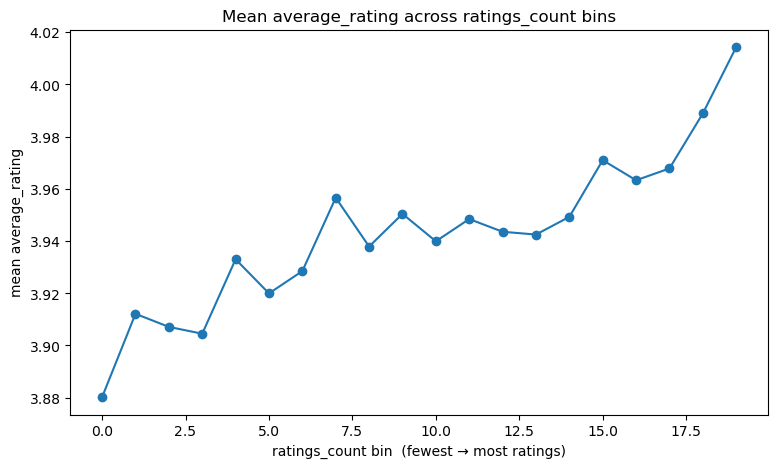

In [23]:
# Binned plotting of avaerage_rating and rating_count(here the books are parted in equal group sizes)
# 20 equal-size groups by ratings_count
clean_books['ratings_count_bin'] = pd.qcut(clean_books['ratings_count'], q=20) 
binned = clean_books.groupby('ratings_count_bin', observed=True)['average_rating'].mean()

plt.figure(figsize=(9,5))
plt.plot(range(len(binned)), binned.values, marker='o')
plt.xlabel('ratings_count bin  (fewest → most ratings)')
plt.ylabel('mean average_rating')
plt.title('Mean average_rating across ratings_count bins')
plt.show()

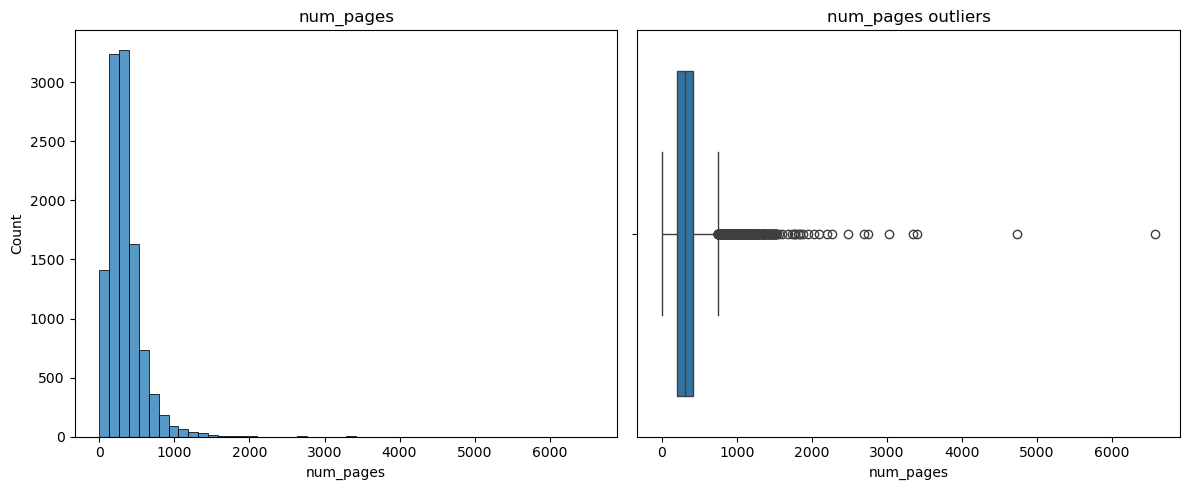

In [24]:
# Hystogram plotting of num_pages showing its distribution and boxplot of num_pages to display the outliers
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(clean_books['num_pages'], bins=50, ax=axes[0]); axes[0].set_title('num_pages')
sns.boxplot(x=clean_books['num_pages'], ax=axes[1]);         axes[1].set_title('num_pages outliers')
plt.tight_layout(); plt.show()

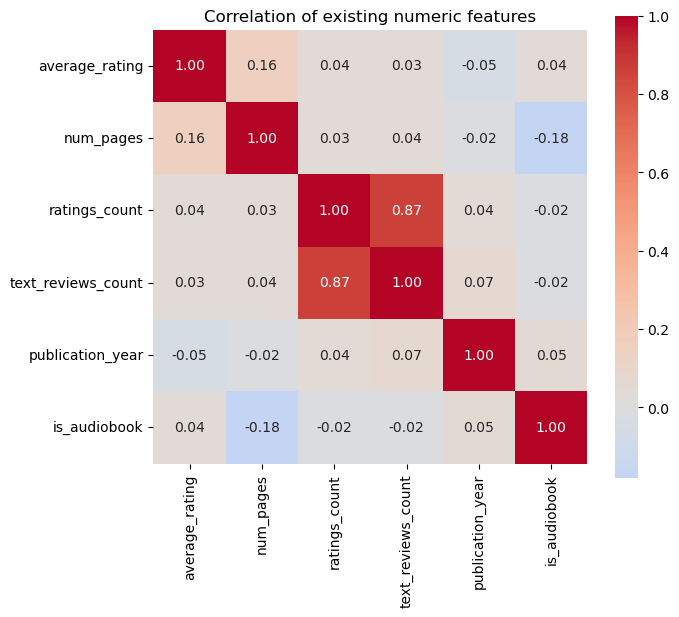

In [25]:
#Correlation heatmap before feature engineering
num_cols = ['average_rating', 'num_pages', 'ratings_count',
            'text_reviews_count', 'publication_year', 'is_audiobook']
plt.figure(figsize=(7,6))
sns.heatmap(clean_books[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation of existing numeric features')
plt.show()

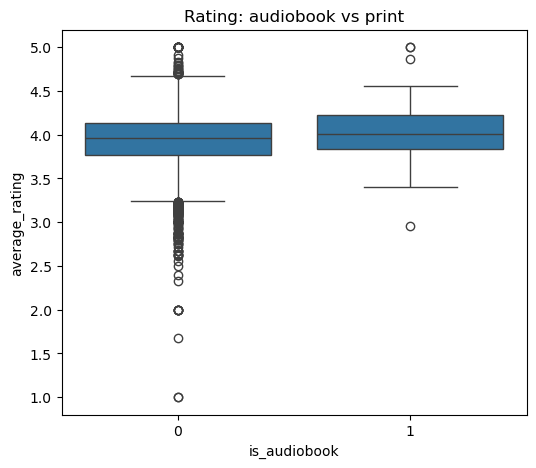

In [26]:
# Plotting average_rating by is_audiobook(where 0= printed books; 1= audiobooks)
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='is_audiobook', y='average_rating')
plt.title('Rating: audiobook vs print')
plt.show()

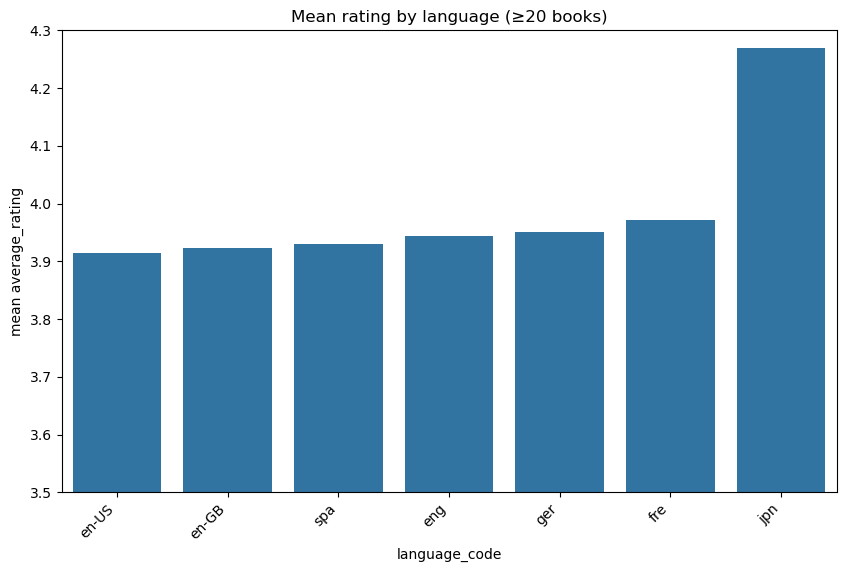

In [27]:
# Mean average_rating by language 
language_ratings = clean_books.groupby('language_code')['average_rating'].agg(['mean','count'])
language_ratings = language_ratings[language_ratings['count'] >= 20].sort_values('mean')   
plt.figure(figsize=(10,6))
sns.barplot(x=language_ratings.index, y=language_ratings['mean'])
plt.ylim(3.5, 4.3)                                       
plt.xticks(rotation=45, ha='right')
plt.title('Mean rating by language (≥20 books)'); plt.ylabel('mean average_rating')
plt.show()

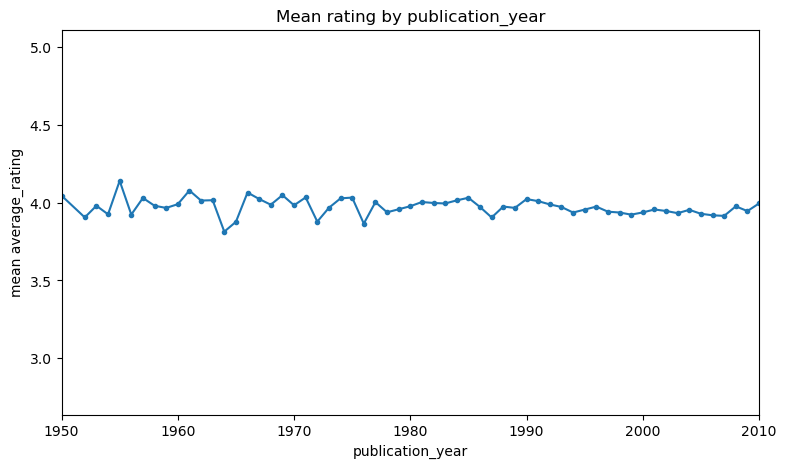

In [42]:
# Mean avarage_rating by Publication_year
# clip noisy early years
yr = clean_books.groupby('publication_year')['average_rating'].mean()
plt.figure(figsize=(9,5))
plt.plot(yr.index, yr.values, marker='.')
plt.xlim(1950, 2010)                                   
plt.title('Mean rating by publication_year')
plt.xlabel('publication_year'); plt.ylabel('mean average_rating')
plt.show()

In [29]:
#Check number of book with 0 rating_count
print("Number of books with no rating count but with an average rating:",(clean_books['ratings_count'] == 0).sum())

Number of books with no rating count but with an average rating: 55


In [30]:
#Check if those books have duplicates on title and authors
#Inconclusive results, only 4 of 55 zero_rating_count books have a sibling edition ,we will not be replacing them by their sibling rating count
zero_rating_books = clean_books.loc[clean_books['ratings_count'] == 0,['title','authors']]
result = pd.merge(clean_books, zero_rating_books, on=['title','authors'], how='inner')
len(result)

59

In [31]:
#create new column for text review per rating, replace the zero division values by 0
clean_books["rev_per_rating"]= clean_books["text_reviews_count"]/clean_books["ratings_count"]
zero_ratings_count = clean_books['ratings_count'] == 0
clean_books.loc[zero_ratings_count, "rev_per_rating"] = 0
print("inf count:", np.isinf(clean_books['rev_per_rating']).sum())
print("nan count:", clean_books['rev_per_rating'].isna().sum())
print("rev_per_rating type:",clean_books['rev_per_rating'].dtype)
clean_books[['title','text_reviews_count','ratings_count','rev_per_rating']].sample(10)

inf count: 0
nan count: 0
rev_per_rating type: float64


,title,text_reviews_count,ratings_count,rev_per_rating
3612,Skinny Dip (Mick Stranahan #2),2602,33459,0.077767
8290,Introducing Philosophy,21,241,0.087137
3705,Skeleton Crew,1186,97092,0.012215
2731,A Long Way Down,3943,65202,0.060474
9893,Dogged Pursuit (Jack and Jamie #5),6,64,0.093750
8314,Cross-X,40,189,0.211640
6613,The Beasties,90,846,0.106383
778,The History of the Siege of Lisbon,62,331,0.187311
875,Love Artist (Harlequin Romance #2860),1,3,0.333333
1275,East of Eden,396,3942,0.100457


In [32]:
#Check title length per character and put it in a new column
clean_books["title_chars"] = clean_books["title"].str.len()
clean_books[['title','title_chars']].sample(10)

,title,title_chars
7617,Burt Dow Deep-Water Man,23
5514,Law of Enclosures,17
8718,Bloodlines,10
9481,Evelina,7
1719,Li Po and Tu Fu: Poems,22
6648,Fear and Trembling,18
8059,Rounding the Mark (Inspector Montalbano #7),43
11029,Mindstar Rising (Greg Mandel #1),32
2565,Hegel's Phenomenology of Spirit,31
10120,Ports of Call,13


In [33]:
#Check title length per words and put it in a new column
clean_books["title_words"] = clean_books["title"].str.split().str.len()
clean_books[['title','title_words']].sample(10)

,title,title_words
1386,Code Complete,2
6666,Irish Traditional Cooking: Over 300 Recipes fr...,9
7919,Riley in the Morning,4
6131,In the Beginning: The Story of the King James ...,21
6653,Lincoln's Dreams,2
3984,Inattentional Blindness,2
5952,The Invisibles Volume 1: Say You Want a Revolu...,9
2331,For Kicks,2
8123,The Razor's Edge,3
4208,The World and Other Places: Stories,6


In [34]:
# check if book is part of a collection  and create a new is_collection column
title_keyword = r'boxed set|box set|omnibus|collection|anthology'
clean_books["is_collection"] = clean_books["title"].str.contains(title_keyword, case = False).astype(int)
print("Number of books belonging to a collection:",clean_books['is_collection'].sum())
print("is_collection type:", clean_books['is_collection'].dtype)
clean_books[clean_books['is_collection']==1][['title',"is_collection"]].sample(15)

Number of books belonging to a collection: 84
is_collection type: int64


,title,is_collection
5947,The Neil Gaiman Audio Collection,1
6354,The Edgar Allan Poe Audio Collection,1
4051,Chekhov's Doctors: A Collection of Chekhov's M...,1
7596,Dragons in the Archives: The Best of Weis & Hi...,1
6,Harry Potter Collection (Harry Potter #1-6),1
9918,The Carl Hiaasen Collection: Lucky You and Sic...,1
10509,PS I Love You Baby Collection,1
3017,The Chronicles of Narnia CD Box Set,1
4284,The Lord of the Rings Millennium Edition Boxed...,1
10910,Remembrance of Things Past (Boxed Set),1


In [35]:
#Check if book is part of a series
clean_books["is_series"] = clean_books["title"].str.contains("#").astype(int)
print("Number of books belonging to a series:",clean_books['is_series'].sum())
print("is_series type:", clean_books['is_series'].dtype)
clean_books[clean_books['is_series']==1][['title',"is_series"]].sample(15)

Number of books belonging to a series: 2379
is_series type: int64


,title,is_series
3643,London Bridges (Alex Cross #10),1
110,The Long Shadow (The Morland Dynasty #6),1
8456,The Closers (Harry Bosch #11; Harry Bosch Univ...,1
3789,Death Note Vol. 4: Love (Death Note #4),1
4546,Murder on the Orient Express (Hercule Poirot #10),1
10293,Polar Shift (NUMA Files #6),1
5768,Forever Peace (The Forever War #2),1
10279,Girl (Girl #1),1
9368,The Lady in Question (Effingtons #7),1
4524,Hallowe'en Party (Hercule Poirot #39),1


In [36]:
#Check if book has a subtitle
clean_books["has_subtitle"] = clean_books["title"].str.contains(":").astype(int)
print("Number of books having a subtitle:",clean_books['has_subtitle'].sum())
print("has subtitles type:", clean_books['has_subtitle'].dtype)
clean_books[clean_books['has_subtitle']==1][['title',"has_subtitle"]].sample(15)

Number of books having a subtitle: 2912
has subtitles type: int64


,title,has_subtitle
4687,Field Notes: The Grace Note of the Canyon Wren,1
10629,Inventing the People: The Rise of Popular Sove...,1
2634,The Orwell Reader: Fiction Essays and Reportage,1
2641,Fanny: Being the True History of the Adventure...,1
2196,Late Victorian Holocausts: El Niño Famines and...,1
221,The Zen of CSS Design: Visual Enlightenment fo...,1
1741,Ride of the Second Horseman: The Birth and Dea...,1
873,Death Note Vol. 4: 恋心 (Death Note #4),1
5086,Algernon Charlie and I: A Writer's Journey: Pl...,1
9260,The Transition of H. P. Lovecraft: The Road to...,1


In [37]:
#Check number of authors
clean_books["num_authors"] = clean_books["authors"].str.count('/') + 1
print("num_authors type:", clean_books['num_authors'].dtype)
clean_books[['title','authors','num_authors']].sample(15)

num_authors type: int64


,title,authors,num_authors
10001,Wyrms,Orson Scott Card,1
10693,David Boring,Daniel Clowes,1
8529,Gimpel the Fool: And Other Stories,Isaac Bashevis Singer/Saul Bellow,2
2148,Antigone's Claim: Kinship Between Life and Death,Judith Butler,1
7501,Tales of Pirx the Pilot,Stanisław Lem/Louis Iribarne,2
7240,Henri Rousseau: Jungles in Paris,Christopher Green/Frances Morris/Nancy Ireson/...,4
1506,The Best Way to Play: A Little Bill Book,Bill Cosby/Varnette P. Honeywood/Varnette Hone...,3
3028,The Forgotten,Elie Wiesel/Stephen Becker,2
6522,Paris Spleen,Charles Baudelaire/Louise Varèse,2
4813,The Feynman Lectures on Physics Vols 7-8,Richard P. Feynman,1


In [38]:
#check if there are multiple authors
clean_books["multiple_authors"] = (clean_books["num_authors"] > 1).astype(int)
print("Books with multiple authors:",clean_books['multiple_authors'].sum())
print("multiple_authors type:", clean_books['multiple_authors'].dtype)
clean_books[clean_books['multiple_authors']==1][['title',"authors","multiple_authors"]].sample(15)

Books with multiple authors: 4552
multiple_authors type: int64


,title,authors,multiple_authors
3704,The First Philosophers: The Presocratics and S...,Robin Waterfield/Anaximander/Anaximenes/Empedo...,1
8732,Apple Pie 4th of July,Janet S. Wong/Margaret Chodos-Irvine,1
2858,Gray Matter and Other Stories from Night Shift,Stephen King/John Glover,1
7363,Witch Grass,Raymond Queneau/Barbara Wright,1
403,The Iliad,Homer/Robert Fagles/Bernard Knox,1
2177,Cattus Petasatus: The Cat in the Hat in Latin,Dr. Seuss/Jennifer Morrish Tunberg/Terence Tun...,1
10358,Circle of Friends,Maeve Binchy/René Huigen/Frans Thomése,1
577,The History of Sexuality Volume 2: The Use of ...,Michel Foucault/Robert Hurley,1
4231,La mujer del viajero en el tiempo,Audrey Niffenegger/Silvia Alemany,1
2010,The Dance of Life: Weaving Sorrows and Blessin...,Henri J.M. Nouwen/Michael Ford,1


In [39]:
# check all possible languages
clean_books['language_code'].value_counts()

language_code
eng      8887
en-US    1409
spa       218
en-GB     214
fre       144
ger        99
jpn        46
mul        19
zho        14
grc        10
por        10
en-CA       7
ita         5
enm         3
lat         3
swe         2
rus         2
nl          1
msa         1
glg         1
wel         1
ara         1
nor         1
tur         1
gla         1
ale         1
Name: count, dtype: int64

In [40]:
#Build a dictionary for languages and assign it to a new column
language_groups = {
    'eng': 'english',
    'en-US': 'english',
    'en-GB': 'english',
    'en-CA': 'english',
    'spa': 'western_european',
    'fre': 'western_european',
    'ger': 'western_european',
    'por': 'western_european',
    'ita': 'western_european',
    'nl': 'western_european',
    'swe': 'western_european',
    'nor': 'western_european',
    'glg': 'western_european',
    'gla': 'western_european',
    'wel': 'western_european',
    'lat': 'classical',
    'enm': 'classical',
    'grc': 'classical',
    'jpn': 'asian', 
    'zho': 'asian', 
    'msa': 'asian',
    'rus': 'other',
    'ara': 'other',
    'tur': 'other',
      'mul': 'other',
    'ale': 'other'
}
clean_books['language_group'] = clean_books['language_code'].map(language_groups)
print("number of empty cells:", clean_books['language_group'].isna().sum())
clean_books['language_group'].value_counts()

number of empty cells: 0


language_group
english             10517
western_european      483
asian                  61
other                  24
classical              16
Name: count, dtype: int64

In [45]:
# Creating new column named Log_ratings count and Log_text_reviews count
clean_books['log_ratings'] = np.log1p(clean_books['ratings_count'])
clean_books['log_text_reviews_count'] = np.log1p(clean_books['text_reviews_count'])
clean_books[["ratings_count","log_ratings", "log_text_reviews_count","text_reviews_count"]].sample(10)
 


,ratings_count,log_ratings,log_text_reviews_count,text_reviews_count
2319,1896,7.548029,5.313206,202
2367,1818,7.506042,4.499810,89
1898,297,5.697093,3.526361,33
5007,2673,7.891331,5.220356,184
5985,12633,9.444147,4.488636,88
4237,159,5.075174,3.688879,39
3137,36303,10.499683,6.086775,439
3908,1738,7.461066,5.463832,235
468,712,6.569481,3.988984,53
5553,3194,8.069342,5.789960,326


In [46]:
# Checking ratio between number of pages and number of authors
clean_books["pages_per_author"] = clean_books["num_pages"]/clean_books["num_authors"]
clean_books["pages_per_author"].describe()

count    11101.000000
mean       262.454399
std        213.526658
min          0.000000
25%        116.000000
50%        224.000000
75%        353.000000
max       6576.000000
Name: pages_per_author, dtype: float64

In [48]:
clean_books[['num_pages','num_authors','pages_per_author']].sample(10)

,num_pages,num_authors,pages_per_author
6968,0,2,0.000000
10367,512,1,512.000000
6446,417,2,208.500000
5582,32,1,32.000000
3709,431,1,431.000000
4079,350,1,350.000000
3358,128,3,42.666667
1329,272,1,272.000000
2237,368,1,368.000000
429,256,2,128.000000


In [51]:
# Check if title has a number
clean_books['title_has_number'] = clean_books['title'].str.contains(r'\d').astype(int)
print("title_has_number type:", clean_books['title_has_number'].dtype)
clean_books[['title','title_has_number']].sample(10)

title_has_number type: int64


,title,title_has_number
2612,Mother Night,0
3554,Messenger (The Giver #3),1
7093,Desde mi cielo,0
2198,Days Between Stations,0
9280,Manic-Depressive Illness: Bipolar Disorders an...,0
7973,Ape and Essence,0
8089,The Secret Diary of Anne Boleyn,0
10034,A Fighting Man of Mars (Barsoom #7),1
10929,Curse Of The Kings,0
8182,Living with Passion and Purpose: Luke (Woman A...,0


In [53]:
# Count Number of Books written by authors
clean_books['author_book_count'] = clean_books.groupby('authors')['authors'].transform('count')
clean_books[['title','authors','author_book_count']].sample(10)
 

,title,authors,author_book_count
9168,The Night Journey,Kathryn Lasky,6
5197,Dostoevsky Kierkegaard Nietzsche and Kafka,William Hubben,1
5526,The Emperor (The Morland Dynasty #11),Cynthia Harrod-Eagles,9
5829,Scavenger (Frank Balenger #2),David Morrell,10
3571,Much Ado about Nothing,William Shakespeare/Samuel West/Amanda Root/Ar...,1
5743,Floaters,Joseph Wambaugh,10
4422,Friends Lovers Chocolate (Isabel Dalhousie #2),Alexander McCall Smith,15
2221,Rachel & Leah (Women of Genesis #3),Orson Scott Card,35
8941,The Damnation Game,Clive Barker,11
5271,Getting the Girl (Wolfe Brothers #3),Markus Zusak,2


In [57]:
# Count Number of Books published by Publishers
clean_books['publisher_book_count'] = clean_books.groupby('publisher')['publisher'].transform('count')
clean_books[['title','publisher','publisher_book_count']].sample(10)

,title,publisher,publisher_book_count
7721,The Professor of Desire,Vintage,318
7867,A Fistful of Charms (The Hollows #4),HarperTorch,48
3451,The Collected Stories,Mariner Books,150
2492,Le Portrait de Dorian Gray,Pocket,17
8297,Early Greek Philosophy,Penguin Books,261
7697,Midnight Jewels,Warner Books,25
2830,Libraries,Schirmer/Mosel,1
4451,Last Train to Paradise: Henry Flagler and the ...,Broadway Books,49
806,Novels 1896–1899: The Other House / The Spoils...,Library of America,52
6853,The Postman Always Rings Twice,Orion,15


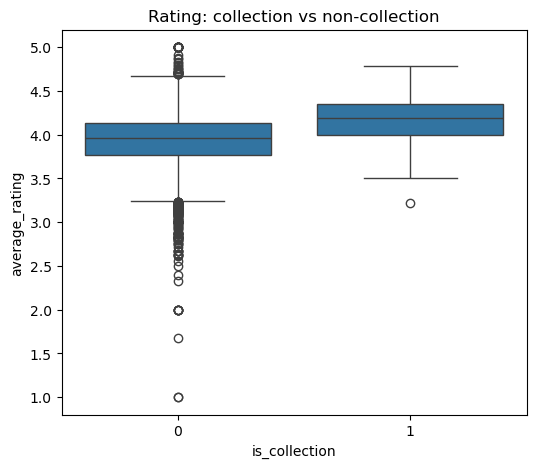

In [60]:
# Plotting average_rating by collection
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='is_collection', y='average_rating') 
plt.title('Rating: collection vs non-collection') 
plt.show()

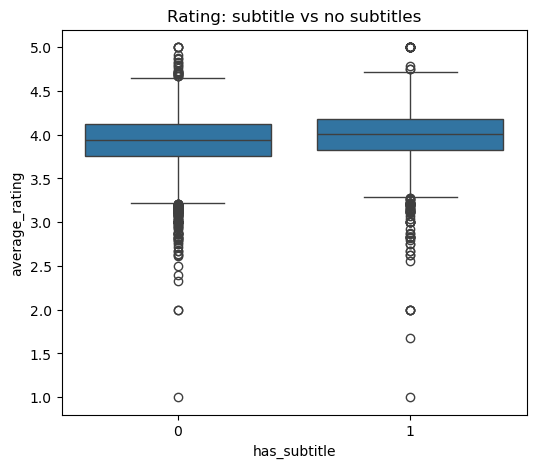

In [62]:
# Plotting average_rating by subtitles
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='has_subtitle', y='average_rating') 
plt.title('Rating: subtitle vs no subtitles') 
plt.show()

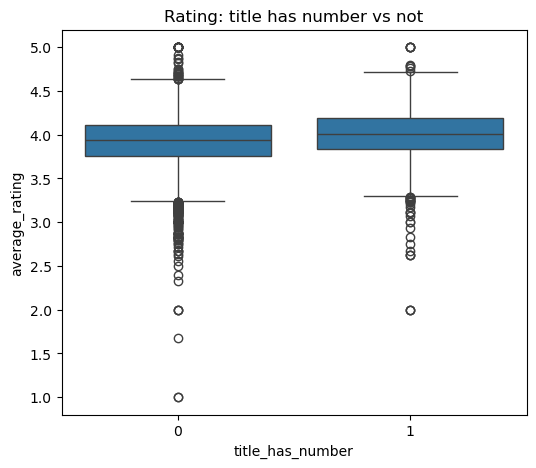

In [63]:
# Plotting average_rating by title_has_number vs not
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='title_has_number', y='average_rating') 
plt.title('Rating: title has number vs not') 
plt.show()

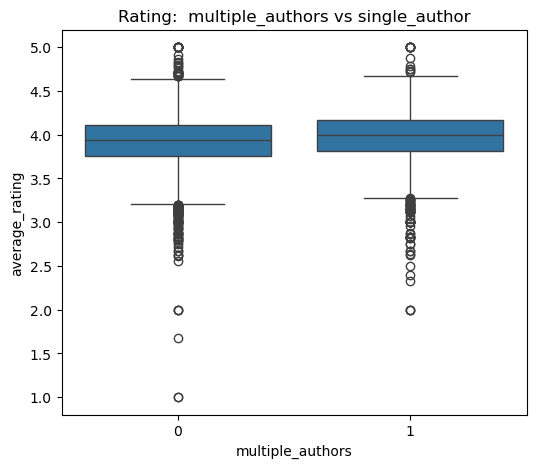

In [67]:
# Plotting average_rating by mutiple_authors 
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='multiple_authors', y='average_rating') 
plt.title('Rating:  multiple_authors vs single_author') 
plt.show()

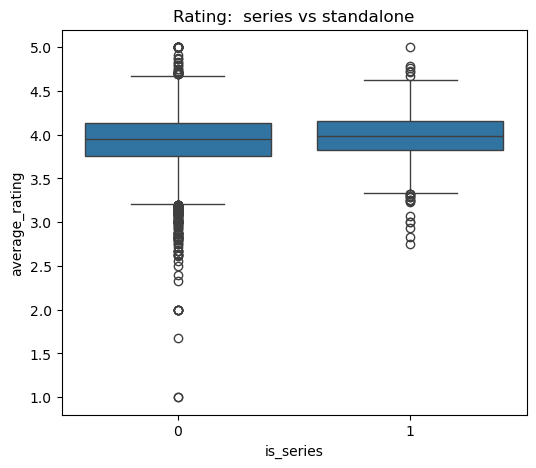

In [68]:
# Plotting average_rating by is_series
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='is_series', y='average_rating') 
plt.title('Rating:  series vs standalone') 
plt.show()

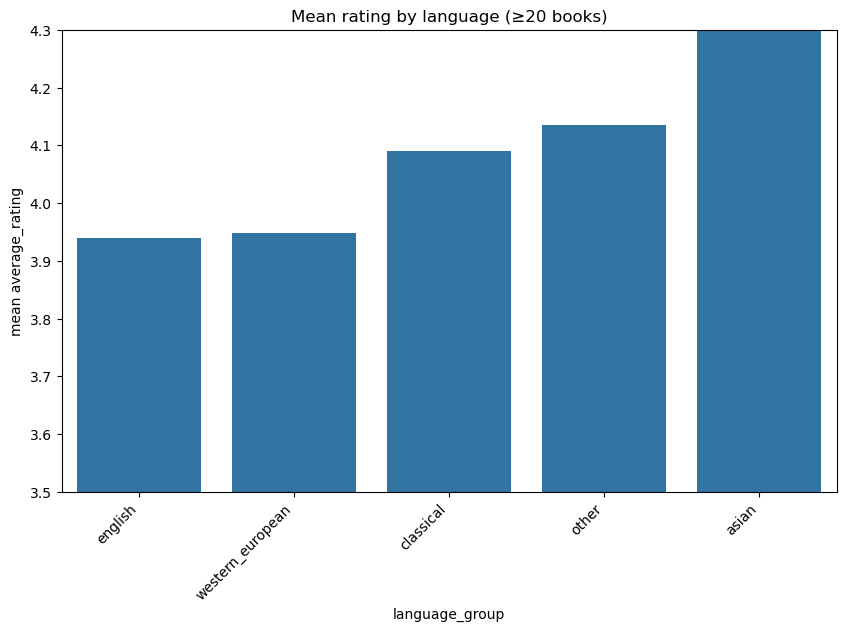

In [72]:
# Mean average_rating by language 
language_ratings = clean_books.groupby('language_group')['average_rating'].agg(['mean','count'])
language_ratings = language_ratings.sort_values('mean')   
plt.figure(figsize=(10,6))
sns.barplot(x=language_ratings.index, y=language_ratings['mean'])
plt.ylim(3.5, 4.3)                                       
plt.xticks(rotation=45, ha='right')
plt.title('Mean rating by language (≥20 books)'); plt.ylabel('mean average_rating')
plt.show()

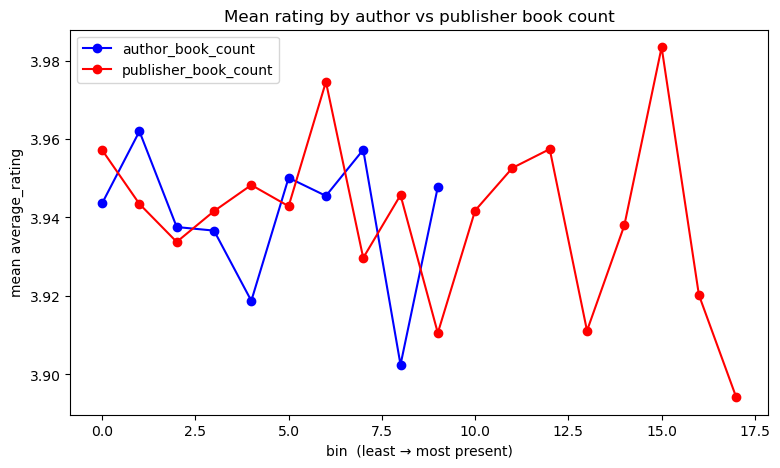

In [81]:
# Binned Plot for average_rating by author and publisher book count 
clean_books['author_count_bin'] = pd.qcut(clean_books['author_book_count'], q=20, duplicates = "drop")
clean_books['publisher_count_bin'] = pd.qcut(clean_books['publisher_book_count'], q=20, duplicates = "drop")
binned_author = clean_books.groupby('author_count_bin', observed=True)['average_rating'].mean()
binned_publisher = clean_books.groupby('publisher_count_bin', observed=True)['average_rating'].mean()
plt.figure(figsize=(9,5))
plt.plot(range(len(binned_author)), binned_author.values, marker='o', color = "blue", label = "author_book_count")
plt.plot(range(len(binned_publisher)), binned_publisher.values, marker='o', color = "red", label = "publisher_book_count")
plt.xlabel('bin  (least → most present)')
plt.ylabel('mean average_rating')
plt.title('Mean rating by author vs publisher book count')
plt.legend()
plt.show()